# **Ejercicio 1**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



--- Resultados Finales XOR ---
Entrada: [-1  1] -> Deseada: [1] -> Red: 0.9835
Entrada: [ 1 -1] -> Deseada: [1] -> Red: 0.9846
Entrada: [-1 -1] -> Deseada: [-1] -> Red: 0.9999
Entrada: [1 1] -> Deseada: [-1] -> Red: -0.9955


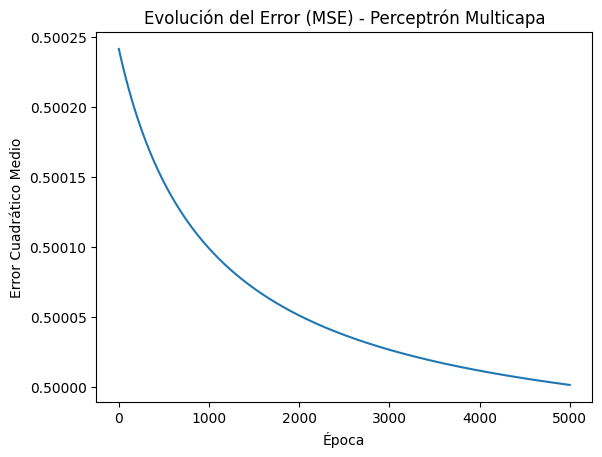

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparación de los datos XOR
x_original = np.array([[-1, 1], [1, -1], [-1, -1], [1, 1]]) # 4 entradas XOR de 2 dimensiones
y = np.array([[1], [1], [-1], [-1]]) # Salidas deseadas para XOR

# Agregar columna de bias (1) a la entrada
bias_input = np.ones((len(x_original), 1))
x = np.hstack((x_original, bias_input))

# 2. Parámetros y Arquitectura
n_entradas = x.shape[1]    # 2 entradas + 1 bias = 3
n_ocultas = 3              # Cantidad de neuronas en capa oculta
n_salidas = 1              # Una única salida para XOR
eta = 0.01               # Tasa de aprendizaje
cota_error = 0.1          # Umbral de error para frenar
max_epocas = 5000 # Número máximo de épocas

# Inicialización de pesos con valores aleatorios entre -2 y 2 (anteriormente -0.5 a 0.5) para evitar gradientes desvanecidos
w_jk = np.random.uniform(-2, 2, (n_ocultas, n_entradas))    # Entrada -> Oculta
W_ij = np.random.uniform(-2, 2, (n_salidas, n_ocultas + 1)) # Oculta -> Salida (+1 por bias)

# Funciones de activación y sus derivadas (Tanh)
def tanh(x): return np.tanh(x)
def d_tanh(x): return 1.0 - np.tanh(x)**2

historial_mse = []

# 3. Bucle de Entrenamiento (Aprendizaje Incremental)
for epoca in range(max_epocas):
    error_cuadratico = 0
    # Mezclamos los índices para tomar ejemplos al azar
    indices = np.arange(len(x))
    np.random.shuffle(indices)

    for idx in indices:
        xi = x[idx].reshape(-1, 1) # Patrón de entrada actual
        target = y[idx].reshape(-1, 1)

        # --- Forward Pass (Propagación hacia adelante) ---
        h_j = np.dot(w_jk, xi)
        V_j = tanh(h_j)

        # Agregar bias a la capa oculta para la siguiente etapa
        V_bias = np.vstack((V_j, [[1]]))

        h_i = np.dot(W_ij, V_bias)
        O_i = tanh(h_i) # Salida final de la red

        # Calcular Error Cuadrático del patrón
        error_cuadratico += 0.5 * np.sum((target - O_i)**2)

        # --- Backward Pass (Retropropagación) ---
        # Delta de salida: g'(h_i) * (target - O_i)
        delta_i = (target - O_i) * d_tanh(h_i)

        # Delta de capa oculta: g'(h_j) * Sumatoria(W_ij * delta_i)
        # Excluimos el peso del bias de la capa oculta para el retroceso
        delta_j = d_tanh(h_j) * np.dot(W_ij[:, :-1].T, delta_i)

        # --- Actualización de Pesos ---
        W_ij += eta * np.outer(delta_i, V_bias)
        w_jk += eta * np.outer(delta_j, xi)

    mse = error_cuadratico / len(x)
    historial_mse.append(mse)

    if mse < cota_error:
        print(f"Convergencia alcanzada en la época {epoca}")
        break

# 4. Verificación de resultados
print("\n--- Resultados Finales XOR ---")
for i in range(len(x)):
    xi = x[i].reshape(-1, 1)
    v = tanh(np.dot(w_jk, xi))
    v_b = np.vstack((v, [[1]]))
    out = tanh(np.dot(W_ij, v_b))
    print(f"Entrada: {x_original[i]} -> Deseada: {y[i]} -> Red: {out.item():.4f}")

# Gráfico de convergencia
plt.plot(historial_mse)
plt.title("Evolución del Error (MSE) - Perceptrón Multicapa")
plt.xlabel("Época"); plt.ylabel("Error Cuadrático Medio")
plt.show()

###Graficos

###Divisiones para frontera de desicion

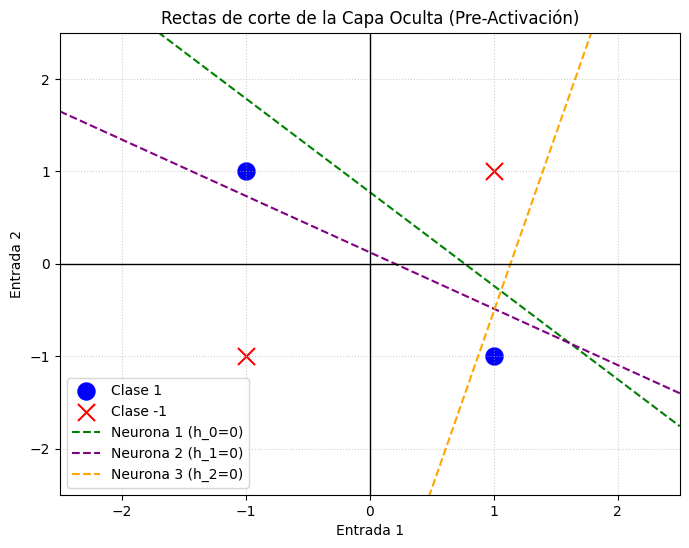

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar el lienzo
plt.figure(figsize=(8, 6))

# 1. Dibujar los 4 puntos del XOR
for i in range(len(x_original)):
    if y[i] == 1:
        plt.scatter(x_original[i, 0], x_original[i, 1], color='blue', marker='o', s=150, label='Clase 1' if i==0 else "")
    else:
        plt.scatter(x_original[i, 0], x_original[i, 1], color='red', marker='x', s=150, label='Clase -1' if i==2 else "")

# Rango de valores para el eje X
x_vals = np.linspace(-2.5, 2.5, 100)

# 2. Dibujar las rectas de las 3 neuronas ocultas
colores = ['green', 'purple', 'orange']

for j in range(n_ocultas):
    # Extraemos los pesos específicos de la neurona 'j'
    w_x = w_jk[j, 0]    # Peso de la entrada 1
    w_y = w_jk[j, 1]    # Peso de la entrada 2
    w_bias = w_jk[j, 2] # Peso del bias

    # Evitar la división por cero si la recta es totalmente vertical
    if abs(w_y) > 1e-5:
        # Aplicamos la fórmula despejada: y = -(w_x * x + w_bias) / w_y
        y_vals = -(w_x * x_vals + w_bias) / w_y
        plt.plot(x_vals, y_vals, color=colores[j], linestyle='--', label=f'Neurona {j+1} (h_{j}=0)')

# Formato del gráfico
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.axhline(0, color='black', linewidth=1) # Eje X
plt.axvline(0, color='black', linewidth=1) # Eje Y
plt.title("Rectas de corte de la Capa Oculta (Pre-Activación)")
plt.xlabel("Entrada 1")
plt.ylabel("Entrada 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Gráfico de la Frontera de Decisión



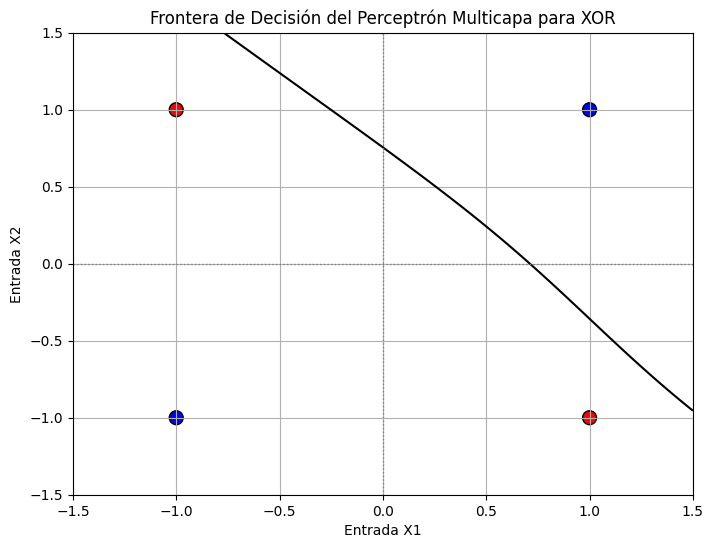

In [ ]:
# Generar una malla de puntos para el espacio de entrada
x1_min, x1_max = x_original[:, 0].min() - 0.5, x_original[:, 0].max() + 0.5
x2_min, x2_max = x_original[:, 1].min() - 0.5, x_original[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                         np.linspace(x2_min, x2_max, 100))

# Preparar los puntos de la malla para la entrada de la red (añadir bias)
Z_input = np.c_[xx1.ravel(), xx2.ravel(), np.ones(xx1.ravel().shape[0])]

# Predecir la salida para cada punto en la malla
predictions = []
for i in range(len(Z_input)):
    xi_mesh = Z_input[i].reshape(-1, 1)

    h_j_mesh = np.dot(w_jk, xi_mesh)
    V_j_mesh = tanh(h_j_mesh)

    V_with_bias_mesh = np.vstack((V_j_mesh, [[1]]))

    h_i_mesh = np.dot(W_ij, V_with_bias_mesh)
    O_i_mesh = tanh(h_i_mesh)
    predictions.append(O_i_mesh.item())

Z = np.array(predictions).reshape(xx1.shape)

# Graficar la frontera de decisión
plt.figure(figsize=(8, 6))
# Eliminado plt.contourf para quitar el relleno de colores
# plt.colorbar(label='Salida de la Red') # La barra de color ya no es necesaria sin contourf
# Añadir una línea de contorno explícita para la frontera de decisión (donde la salida es ~0)
plt.contour(xx1, xx2, Z, levels=[0], colors='black', linestyles='solid', linewidths=1.5) # Reducido grosor para que los puntos se noten más
plt.scatter(x_original[:, 0], x_original[:, 1], c=y.flatten(), cmap='bwr', s=100, edgecolors='k')

# Añadir líneas en x=0 e y=0 (más claras)
plt.axhline(0, color='gray', linestyle='dotted', linewidth=1)
plt.axvline(0, color='gray', linestyle='dotted', linewidth=1)

plt.title('Frontera de Decisión del Perceptrón Multicapa para XOR')
plt.xlabel('Entrada X1')
plt.ylabel('Entrada X2')
plt.grid(True)
plt.show()

###Fontera de decicion con color de fondo


/tmp/ipykernel_2710/1954284736.py:45: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x_original[i, 0], x_original[i, 1], color='red', edgecolors='white', marker='x', s=150)


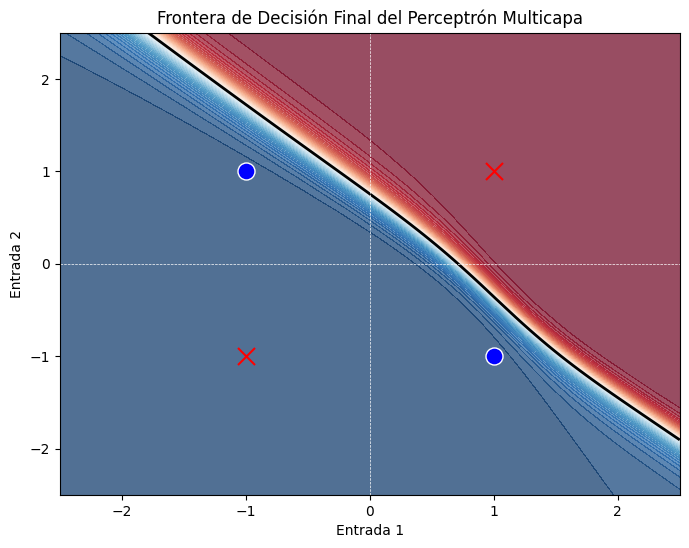

In [ ]:
# 5. Gráfico de la Frontera de Decisión (Fusión no lineal)

# Crear una cuadrícula de 100x100 puntos en el espacio de entrada
x_min, x_max = -2.5, 2.5
y_min, y_max = -2.5, 2.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Aplanar la cuadrícula para pasar los puntos por la red
puntos_grid = np.c_[xx.ravel(), yy.ravel()]

# Agregar el bias (columna de 1s) a todos los puntos de la cuadrícula
bias_grid = np.ones((puntos_grid.shape[0], 1))
entradas_grid = np.hstack((puntos_grid, bias_grid))

# --- Pasar todos los puntos por la red entrenada ---
# Capa oculta
h_j_grid = np.dot(w_jk, entradas_grid.T)
V_j_grid = tanh(h_j_grid)

# Agregar bias a la capa oculta
V_bias_grid = np.vstack((V_j_grid, np.ones((1, V_j_grid.shape[1]))))

# Capa de salida
h_i_grid = np.dot(W_ij, V_bias_grid)
O_i_grid = tanh(h_i_grid)

# Reformatear el resultado para que coincida con la cuadrícula original
Z = O_i_grid.reshape(xx.shape)

# --- Dibujar ---
plt.figure(figsize=(8, 6))

# Dibujar el fondo de color basado en las predicciones de la red
# Usamos un mapa de colores (cmap) que va de Rojo (-1) a Azul (1)
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)

# Dibujar la línea exacta donde la red está indecisa (salida = 0)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)

# Dibujar los 4 puntos del XOR original encima
for i in range(len(x_original)):
    if y[i] == 1:
        plt.scatter(x_original[i, 0], x_original[i, 1], color='blue', edgecolors='white', marker='o', s=150)
    else:
        plt.scatter(x_original[i, 0], x_original[i, 1], color='red', edgecolors='white', marker='x', s=150)

plt.title("Frontera de Decisión Final del Perceptrón Multicapa")
plt.xlabel("Entrada 1")
plt.ylabel("Entrada 2")
plt.axhline(0, color='white', linewidth=0.5, linestyle='--')
plt.axvline(0, color='white', linewidth=0.5, linestyle='--')
plt.show()


# **Ejercicio 2**


Train: [1, 2, 3, 4, 5, 6, 8, 9] Test: [0, 7]
Convergencia en época 12

--- Test (dígitos no vistos) ---
Dígito 0 -> Red: -0.4473 (IMPAR) | Esperado: 1
Dígito 7 -> Red: -0.8685 (IMPAR) | Esperado: -1


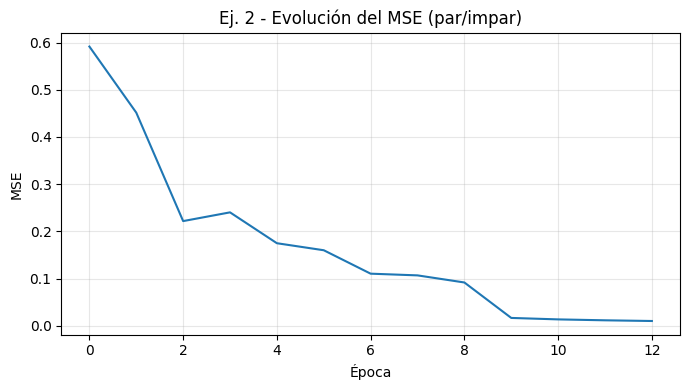

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def cargar_digitos(ruta):
    with open(ruta) as f:
        lineas = [l.split() for l in f if l.strip()]
    datos = np.array(lineas, dtype=float)
    return datos.reshape(10, 35)          #10 dígitos, 35 píxeles cada uno

x_total = cargar_digitos('/content/TP2-ej3-mapa-de-pixeles-digitos-decimales.txt')
x_total = np.where(x_total == 1, 1.0, -1.0)   # pasar 0/1 a -1/+1

#la etiqueta es la PARIDAD (par=+1, impar=-1)
y_total = np.array([[1],[-1],[1],[-1],[1],[-1],[1],[-1],[1],[-1]])

#split train/test con SHUFFLE antes de cortar (evita el sesgo del orden 0..9)
np.random.seed()
orden = np.arange(10)
np.random.shuffle(orden)
idx_train = orden[:8]   # 8 dígitos para entrenar
idx_test  = orden[8:]   # 2 para testear
x_entren = x_total[idx_train]
y_entren = y_total[idx_train]
x_prueba = x_total[idx_test]
y_prueba = y_total[idx_test]
print("Train:", sorted(idx_train.tolist()), "Test:", sorted(idx_test.tolist()))

x_entren_b = np.hstack((x_entren, np.ones((len(x_entren), 1))))
x_prueba_b = np.hstack((x_prueba, np.ones((len(x_prueba), 1))))

n_entradas = x_entren_b.shape[1]   # 35 + bias = 36
n_ocultas = 3
n_salidas = 1
eta = 0.1
cota_error = 0.01
max_epocas = 5000

w_jk = np.random.uniform(-0.5, 0.5, (n_ocultas, n_entradas))
W_ij = np.random.uniform(-0.5, 0.5, (n_salidas, n_ocultas + 1))

def tanh(x): return np.tanh(x)
def d_tanh(x): return 1.0 - np.tanh(x)**2

historial_mse = []

#Entrenamiento
for epoca in range(max_epocas):
    error_cuadratico = 0
    indices = np.arange(len(x_entren_b))
    np.random.shuffle(indices)

    for idx in indices:
        xi = x_entren_b[idx].reshape(-1, 1)
        target = y_entren[idx].reshape(-1, 1)

        h_j = np.dot(w_jk, xi)
        V_j = tanh(h_j)
        V_bias = np.vstack((V_j, [[1]]))
        h_i = np.dot(W_ij, V_bias)
        O_i = tanh(h_i)

        error_cuadratico += 0.5 * np.sum((target - O_i)**2)

        delta_i = (target - O_i) * d_tanh(h_i)
        delta_j = d_tanh(h_j) * np.dot(W_ij[:, :-1].T, delta_i)

        W_ij += eta * np.outer(delta_i, V_bias)
        w_jk += eta * np.outer(delta_j, xi)

    mse = error_cuadratico / len(x_entren_b)
    historial_mse.append(mse)
    if mse < cota_error:
        print(f"Convergencia en época {epoca}")
        break

#Se evalúa la GENERALIZACIÓN sobre dígitos que la red NO vio
print("\n--- Test (dígitos no vistos) ---")
for k, d in enumerate(idx_test):
    xi = x_prueba_b[k].reshape(-1, 1)
    V_j = tanh(np.dot(w_jk, xi))
    V_bias = np.vstack((V_j, [[1]]))
    O_i = tanh(np.dot(W_ij, V_bias))
    resultado = "PAR" if O_i > 0 else "IMPAR"
    print(f"Dígito {d} -> Red: {O_i.item():.4f} ({resultado}) | Esperado: {y_prueba[k].item()}")

plt.figure(figsize=(7, 4))
plt.plot(historial_mse, color='tab:blue')
plt.title("Ej. 2 - Evolución del MSE (par/impar)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



##Grafico

###grafico Salida de la red por dígito

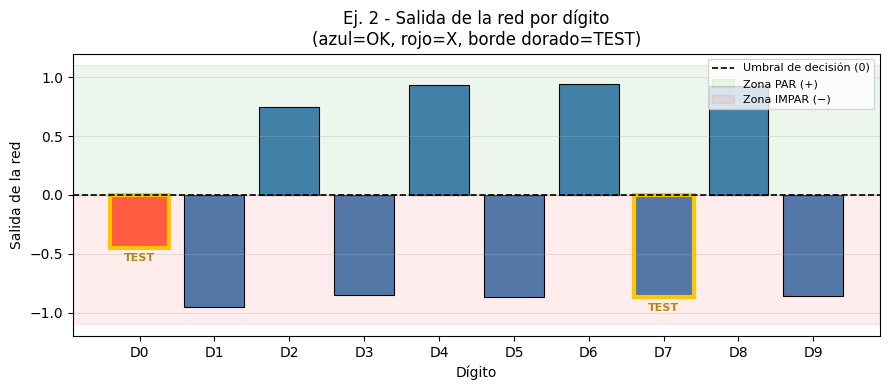

In [ ]:
etiquetas = []
salidas_red = []
colores = []
marcadores_train_test = []

# Pasamos todos los dígitos por la red (train y test)
for d in range(10):
    xi = np.hstack((x_total[d], [1.0])).reshape(-1, 1)
    V_j = tanh(np.dot(w_jk, xi))
    V_bias = np.vstack((V_j, [[1]]))
    O_i = tanh(np.dot(W_ij, V_bias)).item()
    esperado = y_total[d, 0]
    acierto = (np.sign(O_i) == esperado)

    etiquetas.append(f"D{d}")
    salidas_red.append(O_i)
    colores.append('steelblue' if acierto else 'tomato')
    marcadores_train_test.append('TRAIN' if d in idx_train else 'TEST')

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.bar(etiquetas, salidas_red, color=colores, edgecolor='black', linewidth=0.8)

# Línea de decisión en 0
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Umbral de decisión (0)')

# Zona PAR / IMPAR
ax.axhspan(0, 1.1, alpha=0.07, color='green', label='Zona PAR (+)')
ax.axhspan(-1.1, 0, alpha=0.07, color='red', label='Zona IMPAR (−)')

# Marcar cuáles son TEST
for i, (barra, mt) in enumerate(zip(barras, marcadores_train_test)):
    if mt == 'TEST':
        barra.set_edgecolor('gold')
        barra.set_linewidth(3)
        ax.text(i, salidas_red[i] + 0.05 * np.sign(salidas_red[i]),
                'TEST', ha='center', va='bottom' if salidas_red[i] > 0 else 'top',
                fontsize=8, color='darkgoldenrod', fontweight='bold')

ax.set_ylim(-1.2, 1.2)
ax.set_title("Ej. 2 - Salida de la red por dígito\n(azul=OK, rojo=X, borde dorado=TEST)")
ax.set_ylabel("Salida de la red")
ax.set_xlabel("Dígito")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###Leave-One-Out — accuracy por fold

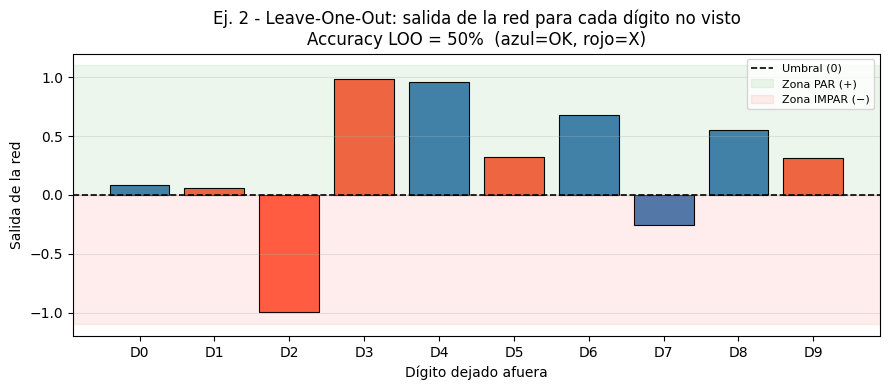


Accuracy LOO = 5/10 = 50%


In [ ]:
# =====================================================================
# GRÁFICO 3: Leave-One-Out — accuracy por fold
# Muestra cuándo la red acierta/falla para cada dígito dejado afuera
# =====================================================================

# Correr LOO (si no lo corriste antes, esto lo hace completo)
resultados_loo = []   # (digito, esperado, salida_red, acierto)

for d_out in range(10):
    tr = np.array([d for d in range(10) if d != d_out])

    # Entrenar sin el dígito d_out
    Xtr = np.hstack((x_total[tr], np.ones((9, 1))))
    Ytr = y_total[tr]
    n_ent_loo = Xtr.shape[1]

    w_loo_jk = np.random.uniform(-0.5, 0.5, (10, n_ent_loo))
    W_loo_ij = np.random.uniform(-0.5, 0.5, (1, 10 + 1))
    np.random.seed(100 + d_out)

    for _ in range(5000):
        ec = 0
        idx_s = np.arange(9); np.random.shuffle(idx_s)
        for idx in idx_s:
            xi = Xtr[idx].reshape(-1, 1); t = Ytr[idx].reshape(-1, 1)
            hj = np.dot(w_loo_jk, xi); Vj = tanh(hj)
            Vb = np.vstack((Vj, [[1]]))
            hi = np.dot(W_loo_ij, Vb); Oi = tanh(hi)
            ec += 0.5 * np.sum((t - Oi)**2)
            di = (t - Oi) * d_tanh(hi)
            dj = d_tanh(hj) * np.dot(W_loo_ij[:, :-1].T, di)
            W_loo_ij += eta * np.outer(di, Vb)
            w_loo_jk += eta * np.outer(dj, xi)
        if ec / 9 < 0.001: break

    # Predecir el dígito dejado afuera
    xi_test = np.hstack((x_total[d_out], [1.0])).reshape(-1, 1)
    Vj = tanh(np.dot(w_loo_jk, xi_test))
    Vb = np.vstack((Vj, [[1]]))
    salida = tanh(np.dot(W_loo_ij, Vb)).item()
    esperado = y_total[d_out, 0]
    acierto = (np.sign(salida) == esperado)
    resultados_loo.append((d_out, esperado, salida, acierto))

# Graficar LOO
digitos_loo = [r[0] for r in resultados_loo]
salidas_loo = [r[2] for r in resultados_loo]
aciertos_loo = [r[3] for r in resultados_loo]
colores_loo = ['steelblue' if a else 'tomato' for a in aciertos_loo]
accuracy_loo = sum(aciertos_loo) / 10 * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f"D{d}" for d in digitos_loo], salidas_loo,
       color=colores_loo, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Umbral (0)')
ax.axhspan(0, 1.1, alpha=0.07, color='green', label='Zona PAR (+)')
ax.axhspan(-1.1, 0, alpha=0.07, color='red', label='Zona IMPAR (−)')
ax.set_ylim(-1.2, 1.2)
ax.set_title(f"Ej. 2 - Leave-One-Out: salida de la red para cada dígito no visto\n"
             f"Accuracy LOO = {accuracy_loo:.0f}%  (azul=OK, rojo=X)")
ax.set_ylabel("Salida de la red")
ax.set_xlabel("Dígito dejado afuera")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAccuracy LOO = {sum(aciertos_loo)}/10 = {accuracy_loo:.0f}%")

# **Ejercicio N°3**

Convergencia en época 406

--- SIN RUIDO ---
Dígito 0 -> red dice 0  OK
Dígito 1 -> red dice 1  OK
Dígito 2 -> red dice 2  OK
Dígito 3 -> red dice 3  OK
Dígito 4 -> red dice 4  OK
Dígito 5 -> red dice 5  OK
Dígito 6 -> red dice 6  OK
Dígito 7 -> red dice 7  OK
Dígito 8 -> red dice 8  OK
Dígito 9 -> red dice 9  OK
Accuracy sin ruido: 100%

--- CON RUIDO p=0.02 ---
Dígito 0: 100.0%
Dígito 1: 100.0%
Dígito 2: 100.0%
Dígito 3: 99.4%
Dígito 4: 100.0%
Dígito 5: 100.0%
Dígito 6: 100.0%
Dígito 7: 100.0%
Dígito 8: 99.2%
Dígito 9: 99.6%
Accuracy global con ruido: 99.8%


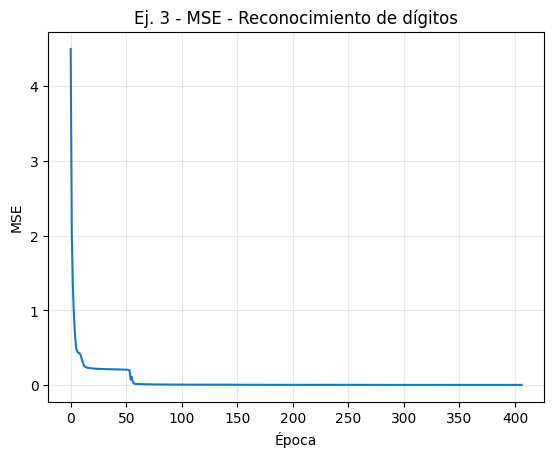

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#1) --Preparación de datos--
def cargar_digitos(ruta):
    with open(ruta) as f:
        lineas = [l.split() for l in f if l.strip()]
    datos = np.array(lineas, dtype=float)
    return datos.reshape(10, 35)

x_total = cargar_digitos('/content/TP2-ej3-mapa-de-pixeles-digitos-decimales.txt')
x_total = np.where(x_total == 1, 1.0, -1.0)

#Entrenamos con LOS 10 dígitos
x = np.hstack((x_total, np.ones((10, 1))))   # 35 píxeles + bias

#Salida bipolar
Y = -np.ones((10, 10))
for d in range(10):
    Y[d, d] = 1.0

#2) --Inicialización--
n_entradas = x.shape[1]    # 36
n_ocultas = 15
n_salidas = 10
eta = 0.1
cota_error = 0.001
max_epocas = 5000

w_jk = np.random.uniform(-0.5, 0.5, (n_ocultas, n_entradas))
W_ij = np.random.uniform(-0.5, 0.5, (n_salidas, n_ocultas + 1))

#3)--Función de activación--
def tanh(x): return np.tanh(x)
def d_tanh(x): return 1.0 - np.tanh(x)**2

historial_mse = []

#4)--Forward--
for epoca in range(max_epocas):
    error_cuadratico = 0
    indices = np.arange(len(x))
    np.random.shuffle(indices)

    for idx in indices:
        xi = x[idx].reshape(-1, 1)
        target = Y[idx].reshape(-1, 1)

        h_j = np.dot(w_jk, xi)
        V_j = tanh(h_j)

        V_bias = np.vstack((V_j, [[1]]))

        h_i = np.dot(W_ij, V_bias)
        O_i = tanh(h_i)

        #4)--error--
        error_cuadratico += 0.5 * np.sum((target - O_i)**2)

        #4)--Backward--
        delta_i = (target - O_i) * d_tanh(h_i)
        delta_j = d_tanh(h_j) * np.dot(W_ij[:, :-1].T, delta_i)

        # --Actualización de pesos--
        W_ij += eta * np.outer(delta_i, V_bias)
        w_jk += eta * np.outer(delta_j, xi)

    mse = error_cuadratico / len(x)
    historial_mse.append(mse)
    if mse < cota_error:
        print(f"Convergencia en época {epoca}")
        break

# --- Evaluación SIN ruido ---
print("\n--- SIN RUIDO ---")
aciertos_sin = 0
for d in range(10):
    xi = x[d].reshape(-1, 1)#pesos aprendidos

    V_j = tanh(np.dot(w_jk, xi))
    V_bias = np.vstack((V_j, [[1]]))

    O_i = tanh(np.dot(W_ij, V_bias))

    #--Predicción--
    pred = np.argmax(O_i) #índice de la salida más activa (argmax)
    ok = (pred == d)
    aciertos_sin += ok
    print(f"Dígito {d} -> red dice {pred}  {'OK' if ok else 'X'}")
print(f"Accuracy sin ruido: {aciertos_sin/10*100:.0f}%")

#evaluación CON RUIDO. Se invierte cada píxel con probabilidad p=0.02
p_ruido = 0.02
n_pruebas = 500    #promediamos 500 versiones ruidosas para tener un resultado estable
aciertos_ruido = np.zeros(10)

for prueba in range(n_pruebas):
    for d in range(10):
        img = x_total[d].copy()
        # máscara aleatoria: True donde se invierte el píxel
        mascara = np.random.random(35) < p_ruido
        img[mascara] *= -1                        # invertir:
        xi = np.append(img, 1.0).reshape(-1, 1)  # agregar bias manualmente
        V_j = tanh(np.dot(w_jk, xi))
        V_bias = np.vstack((V_j, [[1]]))
        O_i = tanh(np.dot(W_ij, V_bias))
        if np.argmax(O_i) == d:
            aciertos_ruido[d] += 1

print("\n--- CON RUIDO p=0.02 ---")
for d in range(10):
    print(f"Dígito {d}: {aciertos_ruido[d]/n_pruebas*100:.1f}%")
print(f"Accuracy global con ruido: {aciertos_ruido.mean()/n_pruebas*100:.1f}%")

plt.plot(historial_mse)
plt.title("Ej. 3 - MSE - Reconocimiento de dígitos")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.show()

###prueba


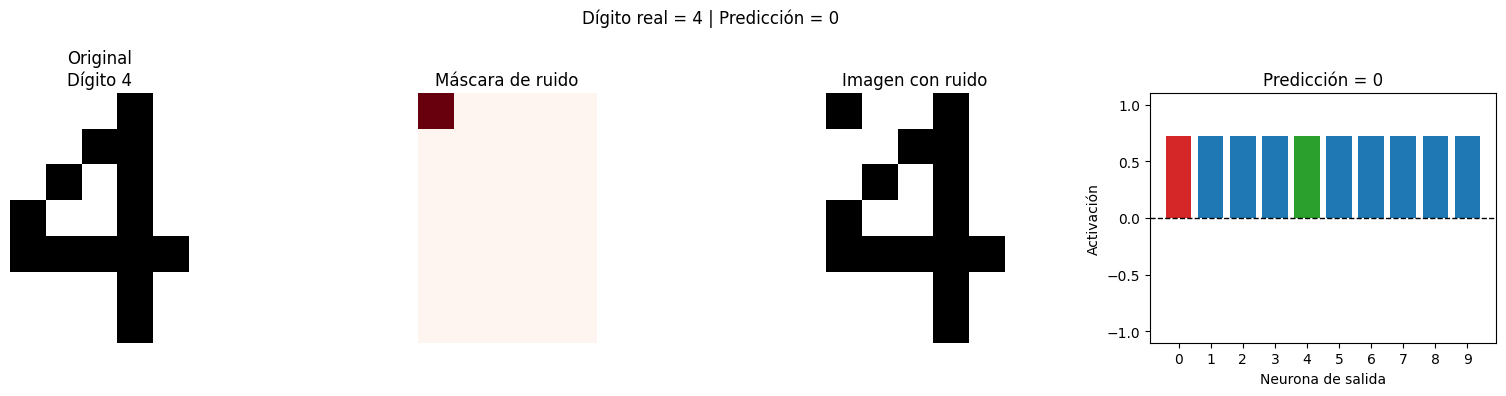


Salidas de la red:
Neurona 0: 0.726 <-- pred


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Elegir dígito y modo
d = 4
buscar_fallo = False   # False: muestra una prueba normal | True: busca un fallo del dígito d

# mismo ruido que el ejercicio
p_ruido = 0.02

# ---------------------------
# Imagen original + ruido
# ---------------------------

img_original = x_total[d].copy()

if buscar_fallo:
    encontrado = False

    for intento in range(50000):
        mascara = np.random.random(35) < p_ruido

        img_ruido = img_original.copy()
        img_ruido[mascara] *= -1

        xi = np.append(img_ruido, 1.0).reshape(-1, 1)
        V_j = tanh(np.dot(w_jk, xi))
        V_bias = np.vstack((V_j, [[1]]))
        O_i = tanh(np.dot(W_ij, V_bias))
        pred = np.argmax(O_i)

        if pred != d:
            encontrado = True
            print(f"Fallo encontrado: dígito real {d} -> predicción {pred} en intento {intento}")
            break

    if not encontrado:
        print("No se encontró ningún fallo. Probá subir p_ruido.")

else:
    mascara = np.random.random(35) < p_ruido

    img_ruido = img_original.copy()
    img_ruido[mascara] *= -1

    xi = np.append(img_ruido, 1.0).reshape(-1, 1)
    V_j = tanh(np.dot(w_jk, xi))
    V_bias = np.vstack((V_j, [[1]]))
    O_i = tanh(np.dot(W_ij, V_bias))
    pred = np.argmax(O_i)

# ---------------------------
# Plot
# ---------------------------

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].imshow(img_original.reshape(7, 5), cmap='gray_r')
axes[0].set_title(f"Original\nDígito {d}")
axes[0].axis('off')

# Máscara
axes[1].imshow(mascara.reshape(7, 5), cmap='Reds')
axes[1].set_title("Máscara de ruido")
axes[1].axis('off')

# Ruidoso
axes[2].imshow(img_ruido.reshape(7, 5), cmap='gray_r')
axes[2].set_title("Imagen con ruido")
axes[2].axis('off')

# Salidas
colores = ['tab:blue'] * 10
colores[d] = 'tab:green'      # dígito real
colores[pred] = 'tab:red'     # predicción

axes[3].bar(range(10), O_i.flatten(), color=colores)
axes[3].set_xticks(range(10))
axes[3].set_xlabel("Neurona de salida")
axes[3].set_ylabel("Activación")
axes[3].set_title(f"Predicción = {pred}")
axes[3].set_ylim(-1.1, 1.1)
axes[3].axhline(0, color='black', linewidth=1, linestyle='--')

plt.suptitle(
    f"Dígito real = {d} | Predicción = {pred}"
)

plt.tight_layout()
plt.show()

print("\nSalidas de la red:")
for i, valor in enumerate(O_i.flatten()):
    marca = ""
    if i == d:
        marca += " <-- real"
    if i == pred:
        marca += " <-- pred"
    print(f"Neurona {i}: {valor:.3f}{marca}")

###GRÁFICO: Accuracy sin ruido vs con ruido por dígito (Ej.3)

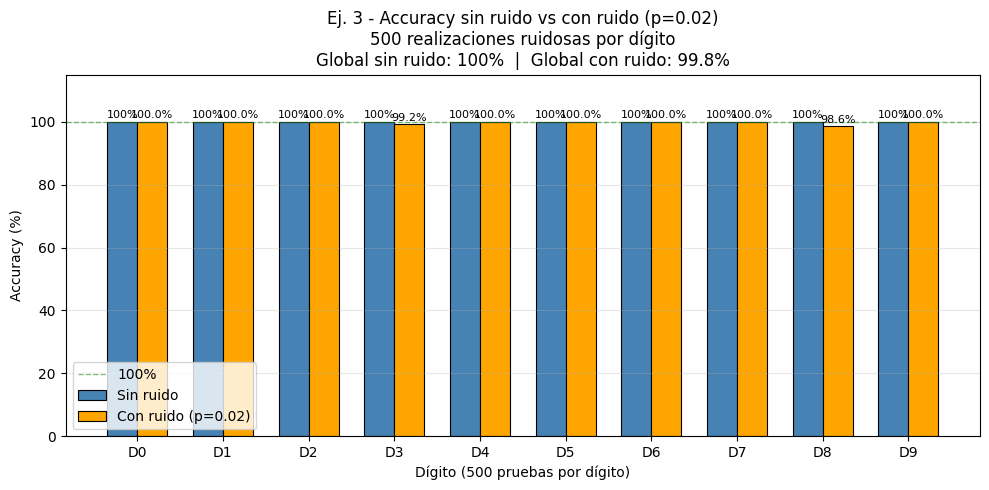


Detalle por dígito:
  Dígito 0: sin ruido 100%  |  con ruido 100.0%
  Dígito 1: sin ruido 100%  |  con ruido 100.0%
  Dígito 2: sin ruido 100%  |  con ruido 100.0%
  Dígito 3: sin ruido 100%  |  con ruido 99.2%
  Dígito 4: sin ruido 100%  |  con ruido 100.0%
  Dígito 5: sin ruido 100%  |  con ruido 100.0%
  Dígito 6: sin ruido 100%  |  con ruido 100.0%
  Dígito 7: sin ruido 100%  |  con ruido 100.0%
  Dígito 8: sin ruido 100%  |  con ruido 98.6%
  Dígito 9: sin ruido 100%  |  con ruido 100.0%

Global sin ruido: 100%
Global con ruido: 99.8%


In [ ]:
# --- Sin ruido: pasar cada dígito limpio por la red ---
acc_sin = np.zeros(10)
for d in range(10):
    # reconstruir entrada con bias desde x_total (los píxeles en -1/+1)
    xi = np.append(x_total[d], 1.0).reshape(-1, 1)
    V_j = tanh(np.dot(w_jk, xi))
    V_bias = np.vstack((V_j, [[1]]))
    O_i = tanh(np.dot(W_ij, V_bias))
    acc_sin[d] = 100.0 if np.argmax(O_i) == d else 0.0

# --- Con ruido p=0.02 (500 realizaciones) ---
p_ruido = 0.02
n_pruebas = 500
acc_con = np.zeros(10)

for prueba in range(n_pruebas):
    for d in range(10):
        img = x_total[d].copy()
        mascara = np.random.random(35) < p_ruido
        img[mascara] *= -1
        xi = np.append(img, 1.0).reshape(-1, 1)
        V_j = tanh(np.dot(w_jk, xi))
        V_bias = np.vstack((V_j, [[1]]))
        O_i = tanh(np.dot(W_ij, V_bias))
        if np.argmax(O_i) == d:
            acc_con[d] += 1

acc_con = acc_con / n_pruebas * 100

# --- Gráfico side-by-side ---
x_pos = np.arange(10)
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

barras_sin = ax.bar(x_pos - ancho/2, acc_sin, ancho,
                    label='Sin ruido', color='steelblue',
                    edgecolor='black', linewidth=0.8)
barras_con = ax.bar(x_pos + ancho/2, acc_con, ancho,
                    label='Con ruido (p=0.02)', color='orange',
                    edgecolor='black', linewidth=0.8)

ax.axhline(100, color='green', linewidth=1,
           linestyle='--', alpha=0.5, label='100%')

# Valores encima de cada barra
for barra in barras_sin:
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, h + 0.5,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=8)
for barra in barras_con:
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, h + 0.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'D{d}' for d in range(10)])
ax.set_ylim(0, 115)
ax.set_xlabel(f"Dígito ({n_pruebas} pruebas por dígito)")
ax.set_ylabel("Accuracy (%)")
ax.set_title(
    f"Ej. 3 - Accuracy sin ruido vs con ruido (p={p_ruido})\n"
    f"{n_pruebas} realizaciones ruidosas por dígito\n"
    f"Global sin ruido: {acc_sin.mean():.0f}%  |  "
    f"Global con ruido: {acc_con.mean():.1f}%"
)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDetalle por dígito:")
for d in range(10):
    print(f"  Dígito {d}: sin ruido {acc_sin[d]:.0f}%  |  con ruido {acc_con[d]:.1f}%")
print(f"\nGlobal sin ruido: {acc_sin.mean():.0f}%")
print(f"Global con ruido: {acc_con.mean():.1f}%")